load dataset

In [1]:
import pandas as pd

# 讀取 CSV 文件
file_path = "../HW3/HW3_text.csv"
df = pd.read_csv(file_path)

# 顯示前幾行數據來檢查內容
df.head()

,message,sentiment
0,I really enjoyed the movie,positive
1,The food was terrible,negative
2,I'm not sure how I feel about this,neutral
3,The service was excellent,positive
4,I had a bad experience,negative


preprocessing on text

In [2]:
import re
from collections import Counter
import matplotlib.pyplot as plt

# 完整的 emoji 正則表達式
# print("Original emoji pattern:", emoji_pattern) # 有括號
# print("Without brackets:", emoji_pattern[1:-1]) # 沒有括號
emoji_pattern = r'[\U0001F600-\U0001F64F' \
                r'\U0001F300-\U0001F5FF' \
                r'\U0001F680-\U0001F6FF' \
                r'\U0001F700-\U0001F77F' \
                r'\U0001F780-\U0001F7FF' \
                r'\U0001F800-\U0001F8FF' \
                r'\U0001F900-\U0001F9FF' \
                r'\U0001FA00-\U0001FA6F' \
                r'\U0001FA70-\U0001FAFF' \
                r'\U00002702-\U000027B0' \
                r'\U000024C2-\U0001F251' \
                r'\U0001F004-\U0001F0CF' \
                r'\U00002B50' \
                r'\U0001F004-\U0001F0CF' \
                r'\U00002700-\U000027BF' \
                r'\U0001F200-\U0001F251' \
                r'\U0001F004-\U0001F0CF' \
                r'\U0001F000-\U0001F02F' \
                r'\U0001F0A0-\U0001F0FF' \
                r'\U0001F600-\U0001F64F' \
                r'\U0001F300-\U0001F5FF' \
                r'\U0001F600-\U0001F64F]'

# 清理文本數據的函數
def clean_text(text):
    """
    Clean text data by:
    1. Converting text to lowercase
    2. Separating emoji characters with spaces
    3. Removing all punctuation except for emoji, letters, numbers, spaces, and ,
    
    Parameters:
    -----------
    text : str
        The input text to be cleaned
        
    Returns:
    --------
    str
        The cleaned text with preserved emojis and basic characters
    """
    text = text.lower()  # 將所有文字轉為小寫
    
    # 找出文本中所有表情符號
    emoji_matches = re.findall(emoji_pattern, text)
    
    # 處理連續表情符號，在它們之間添加空格以便後續分詞
    if len(emoji_matches) > 1:  # 若找到多個表情符號
        for emoji_match in emoji_matches:
            # 在表情符號後添加空格，使其被視為獨立的詞
            separated_emojis = emoji_match + " "
            # 在原文本中替換表情符號，確保每個表情符號被單獨標記
            text = text.replace(emoji_match, separated_emojis)
    
    # 保留字母、數字、空格、表情符號和單引號，移除其他標點符號
    # emoji_pattern[1:-1] 去掉正則表達式兩側的方括號，以便插入到新的正則表達式中
    text = re.sub(r'[^a-zA-Z0-9\s\'' + emoji_pattern[1:-1] + ']', '', text)
    return text

# Clean the text data
df["cleaned_message"] = df["message"].astype(str).apply(clean_text)

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

# 使用已有的 tokenizer 處理文本
from collections import Counter

# 創建 Dataset 和 DataLoader
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns

tokenized the text  
use `train_test_split` to make training dataset and testing dataset

In [4]:
from transformers import BertTokenizer
MAX_WORDS = 5000 
MAX_SEQ_LENGTH = 50  # 設定最大序列長度
EMBEDDING_DIM = 64  # 嵌入維度
HIDDEN_DIM = 128  # RNN 隱藏層維度
BATCH_SIZE = 16
NUM_LAYERS = 3  # RNN 層數

# 繼續使用已有的標籤映射
sentiment_labels = {"positive": 0, "neutral": 1, "negative": 2}
df["label"] = df["sentiment"].map(sentiment_labels)

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 使用 tokenizer 編碼
encoded = tokenizer(
    list(df["cleaned_message"]),
    padding='max_length',   # Padding to the maximum length
    truncation=True,       # Truncate to the maximum length
    max_length=MAX_SEQ_LENGTH, # Maximum sequence length
    return_tensors='pt' # return PyTorch tensors
)

X = encoded["input_ids"]
attention_masks = encoded["attention_mask"]
y = torch.tensor(df["label"].values)

# 拆分 (stratify 用 y 來確保每個類別的比例相同)
X_train, X_test, y_train, y_test, mask_train, mask_test = train_test_split(
    X, y, attention_masks, test_size=0.3, random_state=42, stratify=y
)

# Dataset
train_dataset = TensorDataset(X_train, mask_train, y_train)
test_dataset = TensorDataset(X_test, mask_test, y_test)

# DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

start to train

In [7]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_scheduler
from torch.optim import AdamW
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_CLASSES = 3
LEARNING_RATE = 3e-6
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=NUM_CLASSES).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

Using device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
import torch.nn as nn

Epoch = 15
loss_fn = nn.CrossEntropyLoss()

loss_values = []
valid_loss_values = []
train_accuracy_values = []
valid_accuracy_values = []
best_val_acc = 0

for epoch in range(1, Epoch + 1):
    model.train()
    accuracy = 0.0
    train_loss = 0.0
    for i, (input_ids, attention_mask, labels) in enumerate(train_dataloader):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        # input_ids: encoded text
        # attention_mask: mask for padding tokens, 1 for real tokens, 0 for padding -> focus on real tokens
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        predictions = logits.argmax(dim=1)
        accuracy += (predictions == labels).sum().item()
        train_loss += loss.item() * labels.size(0)

        print(f"Epoch {epoch} | Batch {(i+1)*BATCH_SIZE}/{len(train_dataloader.dataset)} | Loss: {loss.item():.4f} | Accuracy: {(predictions == labels).sum().item()/labels.size(0):.4f}")

    accuracy /= len(train_dataloader.dataset)
    train_loss /= len(train_dataloader.dataset)
    loss_values.append(train_loss)
    train_accuracy_values.append(accuracy)
    print(f"Epoch {epoch}: Train Accuracy: {accuracy:.4f} | Train Loss: {train_loss:.4f}")

    # === Validation ===
    model.eval()
    valid_acc = 0.0
    valid_loss = 0.0

    with torch.no_grad():
        for input_ids, attention_mask, labels in test_dataloader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device).long()

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            predictions = logits.argmax(dim=1)
            valid_acc += (predictions == labels).sum().item()
            valid_loss += loss.item() * labels.size(0)

    valid_acc /= len(test_dataloader.dataset)
    valid_loss /= len(test_dataloader.dataset)
    valid_loss_values.append(valid_loss)
    valid_accuracy_values.append(valid_acc)

    print(f"Epoch {epoch}: Validation Accuracy: {valid_acc:.4f} | Validation Loss: {valid_loss:.4f}")

    if best_val_acc < valid_acc:
        best_val_acc = valid_acc
        torch.save(model.state_dict(), "bert_best_model.pth")


Epoch 1 | Batch 16/408 | Loss: 1.1395 | Accuracy: 0.2500
Epoch 1 | Batch 32/408 | Loss: 1.0635 | Accuracy: 0.4375
Epoch 1 | Batch 48/408 | Loss: 1.0870 | Accuracy: 0.4375
Epoch 1 | Batch 64/408 | Loss: 0.9911 | Accuracy: 0.6250
Epoch 1 | Batch 80/408 | Loss: 1.0158 | Accuracy: 0.5625
Epoch 1 | Batch 96/408 | Loss: 1.0613 | Accuracy: 0.5000
Epoch 1 | Batch 112/408 | Loss: 1.0601 | Accuracy: 0.5000
Epoch 1 | Batch 128/408 | Loss: 1.0182 | Accuracy: 0.5625
Epoch 1 | Batch 144/408 | Loss: 1.1272 | Accuracy: 0.3125
Epoch 1 | Batch 160/408 | Loss: 0.9890 | Accuracy: 0.6250
Epoch 1 | Batch 176/408 | Loss: 1.1799 | Accuracy: 0.3125
Epoch 1 | Batch 192/408 | Loss: 0.9990 | Accuracy: 0.5625
Epoch 1 | Batch 208/408 | Loss: 1.0304 | Accuracy: 0.5000
Epoch 1 | Batch 224/408 | Loss: 0.9785 | Accuracy: 0.5000
Epoch 1 | Batch 240/408 | Loss: 0.9912 | Accuracy: 0.5625
Epoch 1 | Batch 256/408 | Loss: 1.0081 | Accuracy: 0.5000
Epoch 1 | Batch 272/408 | Loss: 1.0406 | Accuracy: 0.4375
Epoch 1 | Batch 288/

show loss, accuracy graph

In [8]:
def draw_loss_variation(loss_values, valid_loss_values, train_accuracy_values, valid_accuracy_values):
    """
    Draw the loss and accuracy variation during training and validation.

    Parameters:
    -----------
    loss_values : list
        List of training loss values
    valid_loss_values : list
        List of validation loss values
    train_accuracy_values : list
        List of training accuracy values
    valid_accuracy_values : list
        List of validation accuracy values

    Returns:
    --------
    None
    """
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(range(1, Epoch+1), loss_values, label='Train Loss', color='blue')
    plt.plot(range(1, Epoch+1), valid_loss_values, label='Validation Loss', color='orange')
    plt.title('Loss Variation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(range(1, Epoch+1), train_accuracy_values, label='Train Accuracy', color='green')
    plt.plot(range(1, Epoch+1), valid_accuracy_values, label='Validation Accuracy', color='red')
    plt.title('Accuracy Variation')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

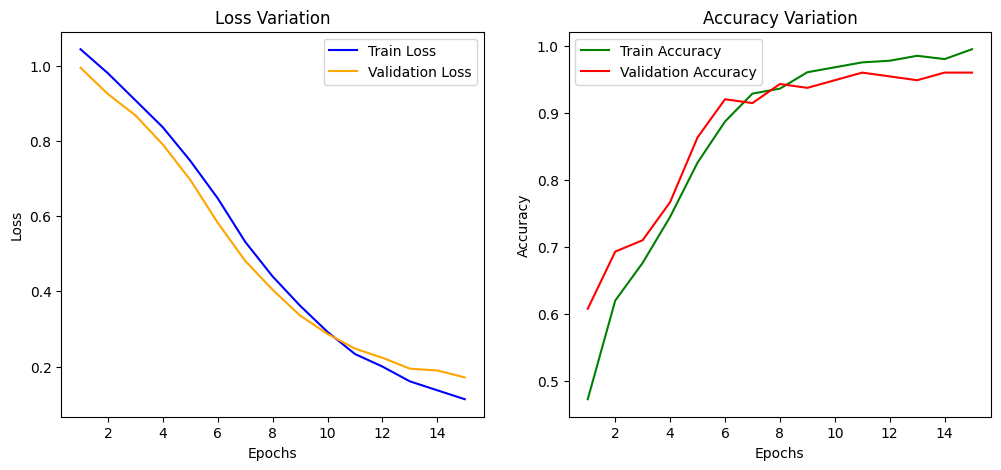

In [24]:
draw_loss_variation(loss_values, valid_loss_values, train_accuracy_values, valid_accuracy_values)

evluate on test dataset

In [9]:
def evaluate(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, attention_mask, labels in dataloader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predicted = torch.argmax(logits, dim=1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [10]:
from transformers import BertForSequenceClassification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=NUM_CLASSES).to(device)
model.load_state_dict(torch.load('bert_best_model.pth'))
all_labels, all_preds = evaluate(model, test_dataloader)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


show confusion matrix

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
def show_confustion(all_labels, all_preds):
    
    labels = ["positive", "neutral", "negative"]

    # 顯示報告
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=labels))

    # 混淆矩陣
    conf_matrix = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    print("Confusion Matrix:")
    print(conf_matrix)

    # 繪製混淆矩陣
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(3), yticklabels=range(3))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


Classification Report:
              precision    recall  f1-score   support

    positive       0.96      0.98      0.97        54
     neutral       0.99      0.92      0.95        78
    negative       0.92      1.00      0.96        44

    accuracy                           0.96       176
   macro avg       0.96      0.97      0.96       176
weighted avg       0.96      0.96      0.96       176

Confusion Matrix:
[[53  1  0]
 [ 2 72  4]
 [ 0  0 44]]


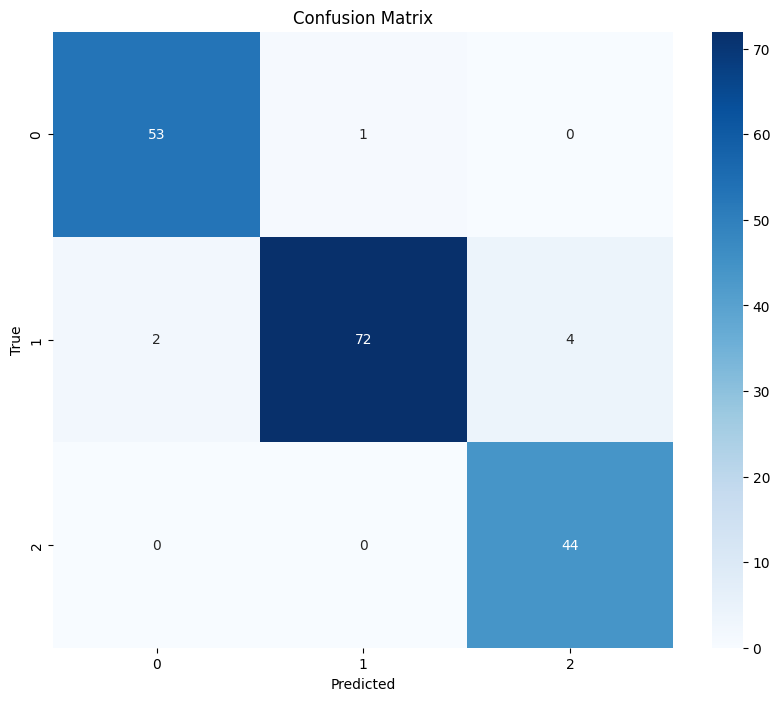

In [14]:
show_confustion(all_labels, all_preds)